# DA Mini Project
* 주제 : 온라인 학습 플랫폼 사용자 행동 패턴 분석
* 개요 :
```
이번 프로젝트는 학습 서비스를 이용하는 독자들 중 누가 서비스 구독을 연장할지 예측하기 위한 사전 파악에 초점을 맞추고 있습니다. 우리의 목표는 유저들의 학습 습관, 선호도, 이용 행태 등 다양한 측면을 면밀히 분석하는 것입니다.


이를 위해, 우리는 유저들의 학습 패턴, 서비스 이용 시간, 콘텐츠에 대한 반응, 그리고 이들이 얼마나 자주 서비스를 이용하는지 등 다양한 데이터를 수집하고 분석할 계획입니다. 이 데이터는 유저들이 서비스에 얼마나 만족하고 있는지, 어떤 요소들이 그들의 구독 결정에 영향을 미치는지 이해하는 데 중요한 역할을 할 것입니다.
```
* 데이터셋 : mini.csv
    * 메타데이터
        * user_id: 사용자의 고유 식별자
        * subscription_duration: 사용자가 서비스에 가입한 기간 (월)
        * recent_login_time: 사용자가 마지막으로 로그인한 시간 (일)
        * average_login_time:  사용자의 일반적인 로그인 시간
        * average_time_per_learning_session: 각 학습 세션에 소요된 평균 시간 (분)
        * monthly_active_learning_days: 월간 활동적인 학습 일수
        * total_completed_courses: 완료한 총 코스 수
        * recent_learning_achievement: 최근 학습 성취도
        * abandoned_learning_sessions: 중단된 학습 세션 수
        * community_engagement_level: 커뮤니티 참여도
        * preferred_difficulty_level: 선호하는 난이도
        * subscription_type: 구독 유형
        * customer_inquiry_history: 고객 문의 이력
        * payment_pattern : 사용자의 지난 3개월 간의 결제 패턴을 10진수로 표현한 값.
          - 7: 3개월 모두 결제함
          - 6: 첫 2개월은 결제했으나 마지막 달에는 결제하지 않음
          - 5: 첫 달과 마지막 달에 결제함
          - 4: 첫 달에만 결제함
          - 3: 마지막 2개월에 결제함
          - 2: 가운데 달에만 결제함
          - 1: 마지막 달에만 결제함
          - 0: 3개월 동안 결제하지 않음
        * target: 사용자가 다음 달에도 구독을 계속할지 (1) 또는 취소할지 (0)를 나타냄

In [1]:
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
mini_data = pd.read_table('data/mini.csv',sep=',')

In [4]:
mini_data.head()

,user_id,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,preferred_difficulty_level,subscription_type,customer_inquiry_history,payment_pattern,target
0,b919c29d,13,14,14.946163,8.427187,18,16,68.360455,3,4,Low,Basic,4,5,0
1,a0a60abb,16,18,18.453224,72.646087,16,13,97.567322,2,3,Medium,Basic,1,6,1
2,b9f171ae,22,1,16.195228,21.774492,13,14,94.358763,3,4,Medium,Premium,0,7,1
3,5dc0ba8b,1,19,17.628656,42.659066,19,18,70.153228,0,3,Low,Basic,1,0,1
4,65c83654,4,5,21.390656,30.744287,19,10,81.917908,2,4,Medium,Basic,3,0,1


In [5]:
mini_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   user_id                            10000 non-null  object 
 1   subscription_duration              10000 non-null  int64  
 2   recent_login_time                  10000 non-null  int64  
 3   average_login_time                 10000 non-null  float64
 4   average_time_per_learning_session  10000 non-null  float64
 5   monthly_active_learning_days       10000 non-null  int64  
 6   total_completed_courses            10000 non-null  int64  
 7   recent_learning_achievement        10000 non-null  float64
 8   abandoned_learning_sessions        10000 non-null  int64  
 9   community_engagement_level         10000 non-null  int64  
 10  preferred_difficulty_level         10000 non-null  object 
 11  subscription_type                  10000 non-null  obje

In [6]:
mini_data.describe(include='all')

,user_id,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,preferred_difficulty_level,subscription_type,customer_inquiry_history,payment_pattern,target
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000
unique,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN
top,b919c29d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,Basic,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4992,5979,NaN,NaN,NaN
mean,NaN,11.897400,15.013200,14.994076,54.917720,12.545400,12.227500,75.029513,3.043600,3.886100,NaN,NaN,2.010500,3.502900,0.619900
std,NaN,6.600896,8.362573,3.001869,56.024310,6.932239,3.634125,9.968529,1.755052,1.262175,NaN,NaN,1.420983,2.311261,0.485435
min,NaN,1.000000,1.000000,2.366189,0.011515,1.000000,1.000000,35.941755,0.000000,1.000000,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,6.000000,8.000000,13.025597,15.276611,7.000000,10.000000,68.278054,2.000000,3.000000,NaN,NaN,1.000000,1.000000,0.000000
50%,NaN,12.000000,15.000000,14.979228,37.578818,13.000000,12.000000,75.126061,3.000000,4.000000,NaN,NaN,2.000000,4.000000,1.000000
75%,NaN,18.000000,22.000000,16.995340,75.584200,19.000000,15.000000,81.718976,4.000000,5.000000,NaN,NaN,3.000000,6.000000,1.000000


In [7]:
len(mini_data)

10000

In [8]:
mini_data.describe()

,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,customer_inquiry_history,payment_pattern,target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.897400,15.013200,14.994076,54.917720,12.545400,12.227500,75.029513,3.043600,3.886100,2.010500,3.502900,0.619900
std,6.600896,8.362573,3.001869,56.024310,6.932239,3.634125,9.968529,1.755052,1.262175,1.420983,2.311261,0.485435
min,1.000000,1.000000,2.366189,0.011515,1.000000,1.000000,35.941755,0.000000,1.000000,0.000000,0.000000,0.000000
25%,6.000000,8.000000,13.025597,15.276611,7.000000,10.000000,68.278054,2.000000,3.000000,1.000000,1.000000,0.000000
50%,12.000000,15.000000,14.979228,37.578818,13.000000,12.000000,75.126061,3.000000,4.000000,2.000000,4.000000,1.000000
75%,18.000000,22.000000,16.995340,75.584200,19.000000,15.000000,81.718976,4.000000,5.000000,3.000000,6.000000,1.000000
max,23.000000,29.000000,26.998490,503.372616,24.000000,27.000000,112.643828,12.000000,5.000000,10.000000,7.000000,1.000000


In [9]:
mini_data.isnull().sum()

user_id                              0
subscription_duration                0
recent_login_time                    0
average_login_time                   0
average_time_per_learning_session    0
monthly_active_learning_days         0
total_completed_courses              0
recent_learning_achievement          0
abandoned_learning_sessions          0
community_engagement_level           0
preferred_difficulty_level           0
subscription_type                    0
customer_inquiry_history             0
payment_pattern                      0
target                               0
dtype: int64

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 투입 시간

In [11]:
type(mini_data['subscription_duration'][0])

numpy.int64

In [12]:
import matplotlib as mpl
import matplotlib.pylab as plt
import koreanize_matplotlib
import numpy as np

# 2. 참여도

In [13]:
import matplotlib.pyplot as plt

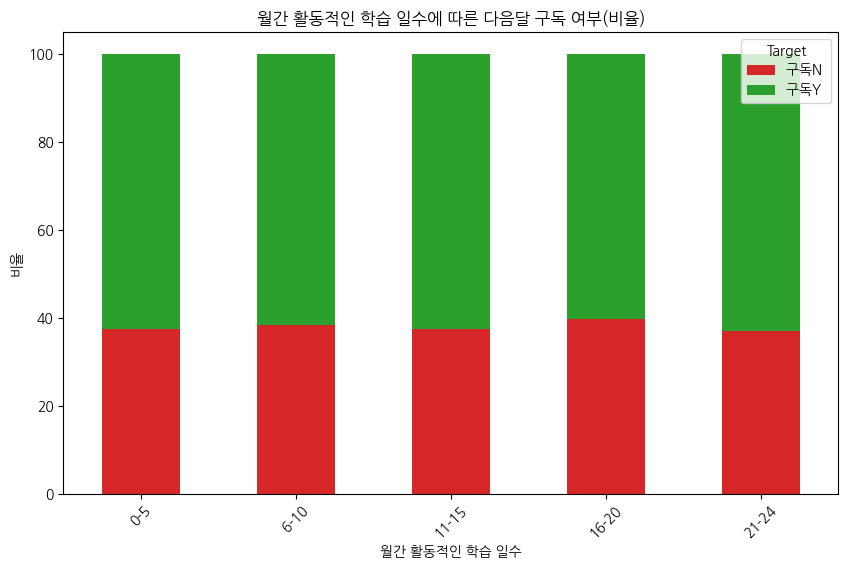

In [14]:
# 구간 나누기
bins = [0, 5, 10, 15, 20, 24]
labels = ['0-5', '6-10', '11-15', '16-20', '21-24']
mini_data['active_days_bin'] = pd.cut(mini_data['monthly_active_learning_days'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['active_days_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#d62728', '#2ca02c'])
plt.title('월간 활동적인 학습 일수에 따른 다음달 구독 여부(비율)')
plt.xlabel('월간 활동적인 학습 일수')
plt.ylabel('비율')
plt.legend(title='Target', labels=['구독N ', '구독Y '])
plt.xticks(rotation=45)

plt.show()

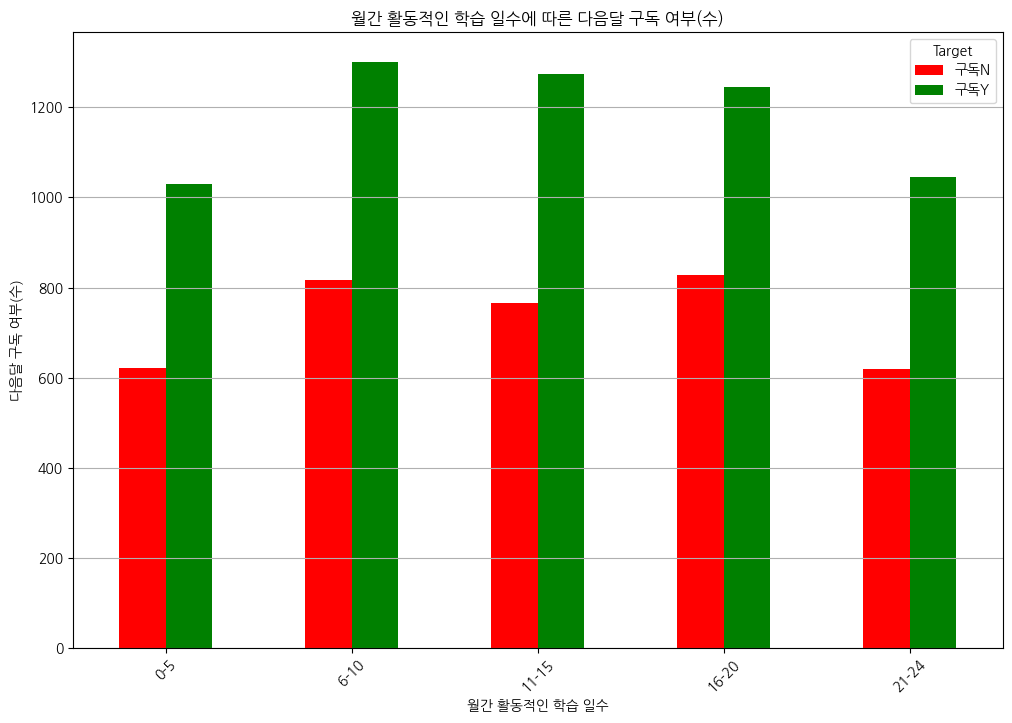

In [15]:
# 구간 나누기
bins = [0, 5, 10, 15, 20, 24]
labels = ['0-5', '6-10', '11-15', '16-20', '21-24']
mini_data['active_days_bin'] = pd.cut(mini_data['monthly_active_learning_days'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['active_days_bin', 'target']).size().unstack(fill_value=0)

# 바 그래프 생성
fig, ax = plt.subplots(figsize=(12, 8))
bin_counts.plot(kind='bar', ax=ax, color=['red', 'green'])

# 그래프 세부 설정
ax.set_title('월간 활동적인 학습 일수에 따른 다음달 구독 여부(수)')
ax.set_xlabel('월간 활동적인 학습 일수')
ax.set_ylabel('다음달 구독 여부(수)')
ax.legend(title='Target', labels=['구독N', '구독Y'])
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

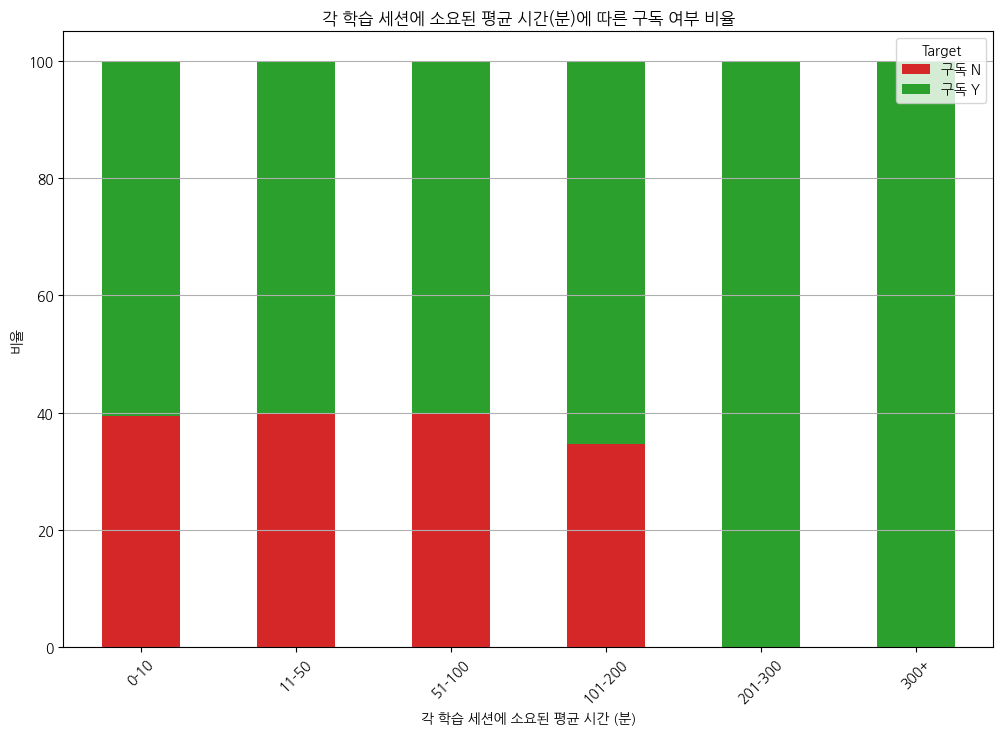

In [16]:
# 구간 설정
bins = [0, 10, 50, 100, 200, 300, 504]
labels = ['0-10', '11-50', '51-100', '101-200', '201-300', '300+']

# 데이터 구간 나누기
mini_data['time_bin'] = pd.cut(mini_data['average_time_per_learning_session'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['time_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('각 학습 세션에 소요된 평균 시간(분)에 따른 구독 여부 비율')
plt.xlabel('각 학습 세션에 소요된 평균 시간 (분)')
plt.ylabel('비율')
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 범례 이름 설정
plt.legend(title='Target', labels=['구독 N', '구독 Y'])

plt.show()

In [55]:
atpls=mini_data['average_time_per_learning_session'].value_counts().sort_index() 
print(atpls)

average_time_per_learning_session
0.011515      1
0.012562      1
0.013535      1
0.017473      1
0.029555      1
             ..
444.324058    1
447.095844    1
470.289498    1
490.233443    1
503.372616    1
Name: count, Length: 10000, dtype: int64


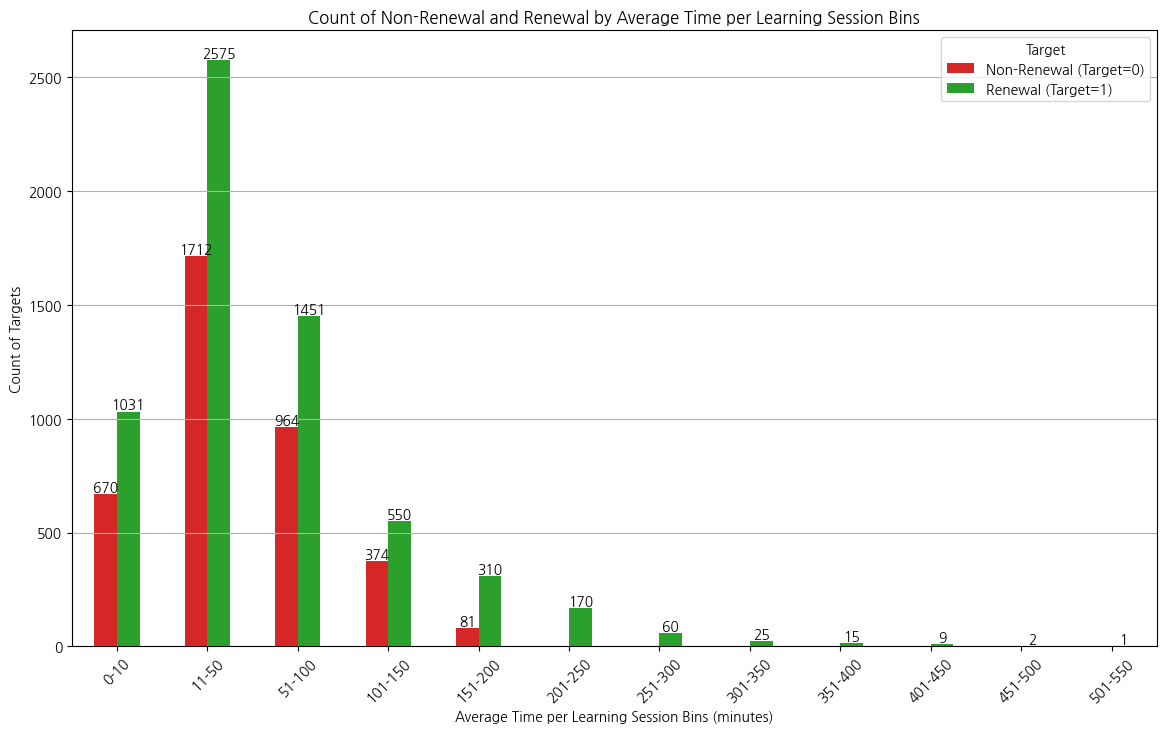

In [56]:

# 구간 설정
bins = [0, 10, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550]  # 최소값과 최대값 포함한 구간 설정
labels = ['0-10', '11-50', '51-100', '101-150', '151-200', '201-250', '251-300', '301-350', '351-400', '401-450', '451-500', '501-550']

# 데이터 구간 나누기
mini_data['time_bin'] = pd.cut(mini_data['average_time_per_learning_session'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['time_bin', 'target']).size().unstack(fill_value=0)

# 바 차트 시각화
fig, ax = plt.subplots(figsize=(14, 8))
bin_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])

# 그래프 세부 설정
ax.set_title('Count of Non-Renewal and Renewal by Average Time per Learning Session Bins')
ax.set_xlabel('Average Time per Learning Session Bins (minutes)')
ax.set_ylabel('Count of Targets')
ax.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 각 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 수치가 0보다 클 때만 표시
        ax.text(p.get_x() + p.get_width() / 2., height, f'{int(height)}', ha='center', va='bottom')

plt.show()

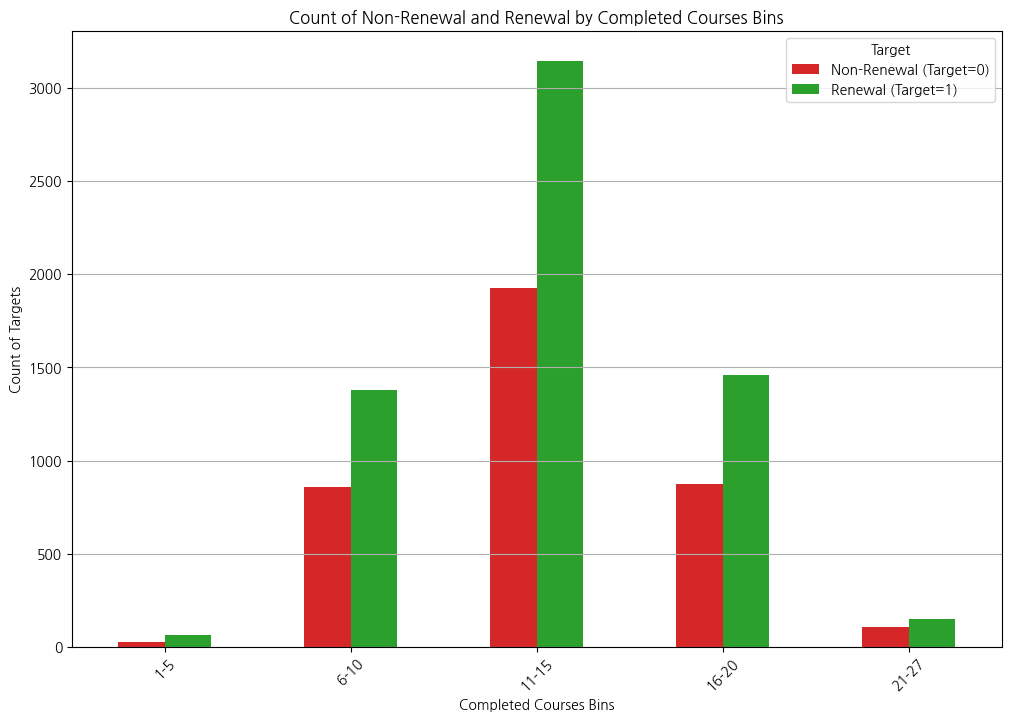

In [17]:
# 구간 설정
bins = [0, 5, 10, 15, 20, 27]  # 최대값 27을 포함
labels = ['1-5', '6-10', '11-15', '16-20', '21-27']

# 데이터 구간 나누기
mini_data['completed_courses_bin'] = pd.cut(mini_data['total_completed_courses'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['completed_courses_bin', 'target']).size().unstack(fill_value=0)

# 바 차트 생성
fig, ax = plt.subplots(figsize=(12, 8))
bin_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])

# 그래프 세부 설정
ax.set_title('Count of Non-Renewal and Renewal by Completed Courses Bins')
ax.set_xlabel('Completed Courses Bins')
ax.set_ylabel('Count of Targets')
ax.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

plt.show()

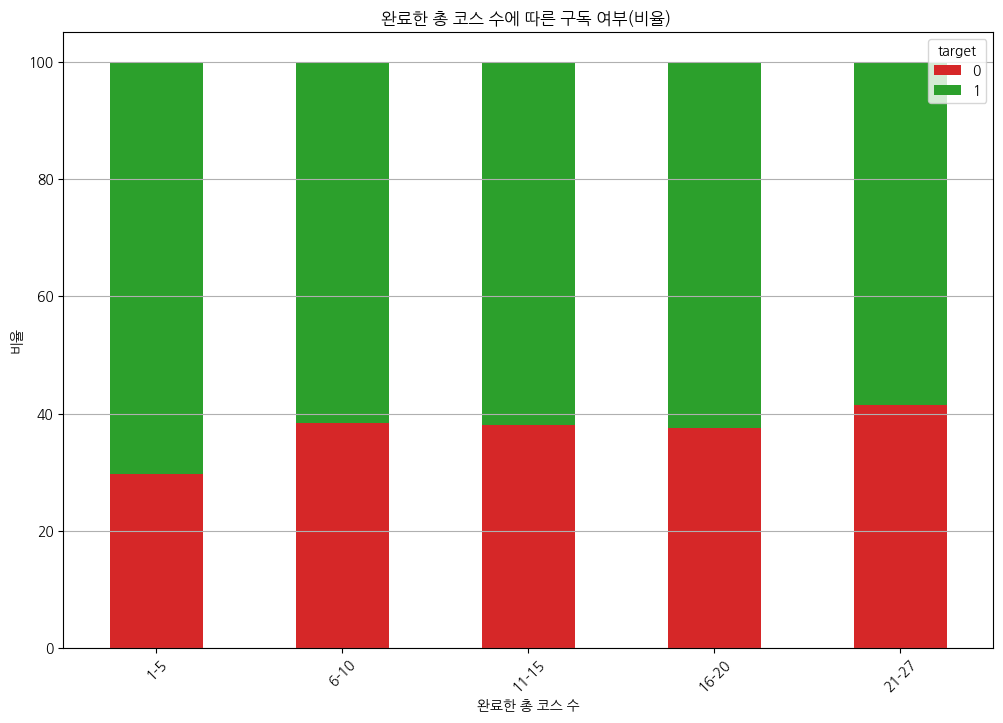

In [18]:
# 구간 설정
bins = [0, 5, 10, 15, 20, 27]  # 최대값 27을 포함
labels = ['1-5', '6-10', '11-15', '16-20', '21-27']

# 데이터 구간 나누기
mini_data['completed_courses_bin'] = pd.cut(mini_data['total_completed_courses'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['completed_courses_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('완료한 총 코스 수에 따른 구독 여부(비율) ')
plt.xlabel('완료한 총 코스 수')
plt.ylabel('비율')
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

plt.show()

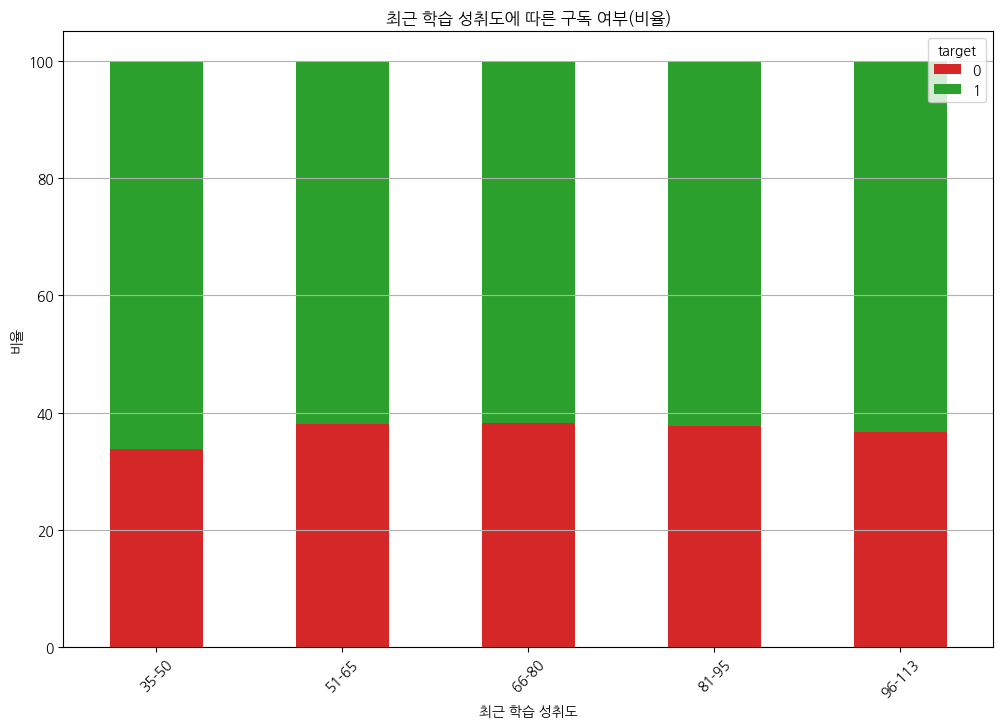

In [19]:
# 구간 설정
bins = [35, 50, 65, 80, 95, 113]  # 최소값과 최대값을 포함하고 세밀하게 구간 분할
labels = ['35-50', '51-65', '66-80', '81-95', '96-113']

# 데이터 구간 나누기
mini_data['achievement_bin'] = pd.cut(mini_data['recent_learning_achievement'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['achievement_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('최근 학습 성취도에 따른 구독 여부(비율)')
plt.xlabel('최근 학습 성취도')
plt.ylabel('비율')
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

plt.show()

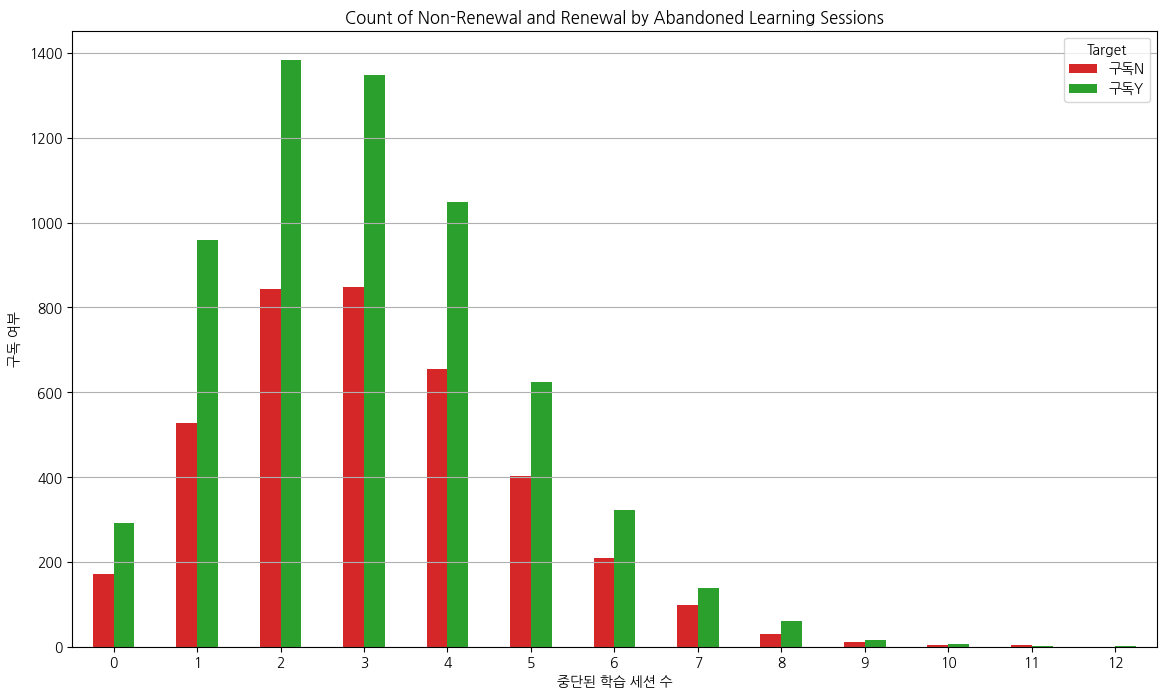

In [31]:
# 구간 설정
bins = list(range(0, 14))  # 0부터 12까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(13)]  # 0부터 12까지의 라벨

# 데이터 구간 나누기
mini_data['abandoned_bin'] = pd.cut(mini_data['abandoned_learning_sessions'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['abandoned_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 바 차트 생성
fig, ax = plt.subplots(figsize=(14, 8))
bin_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])

# 그래프 세부 설정
ax.set_title('Count of Non-Renewal and Renewal by Abandoned Learning Sessions')
ax.set_xlabel('중단된 학습 세션 수')
ax.set_ylabel('구독 여부')
ax.legend(title='Target', labels=['구독N', '구독Y'])
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가

plt.show()

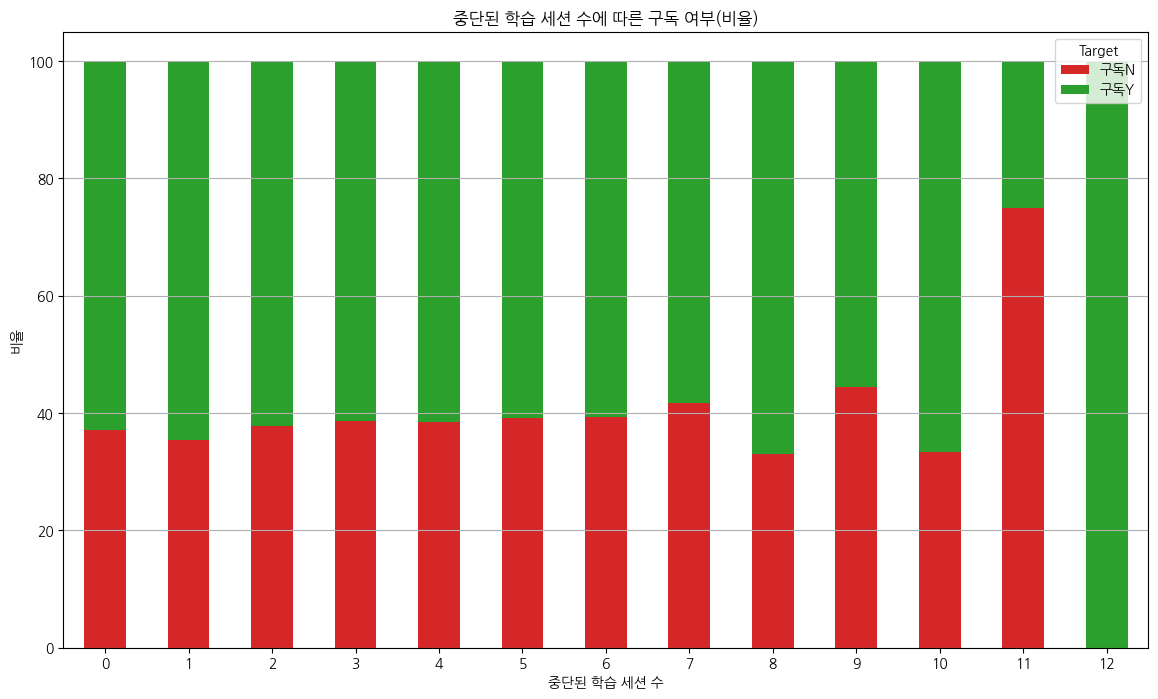

In [32]:
# 구간 설정
bins = list(range(0, 14))  # 0부터 12까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(13)]  # 0부터 12까지의 라벨

# 데이터 구간 나누기
mini_data['abandoned_bin'] = pd.cut(mini_data['abandoned_learning_sessions'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['abandoned_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(14, 8), color=['#d62728', '#2ca02c'])
plt.title('중단된 학습 세션 수에 따른 구독 여부(비율)')
plt.xlabel('중단된 학습 세션 수')
plt.ylabel('비율')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가

plt.legend(title='Target', labels=['구독N', '구독Y'])


plt.show()

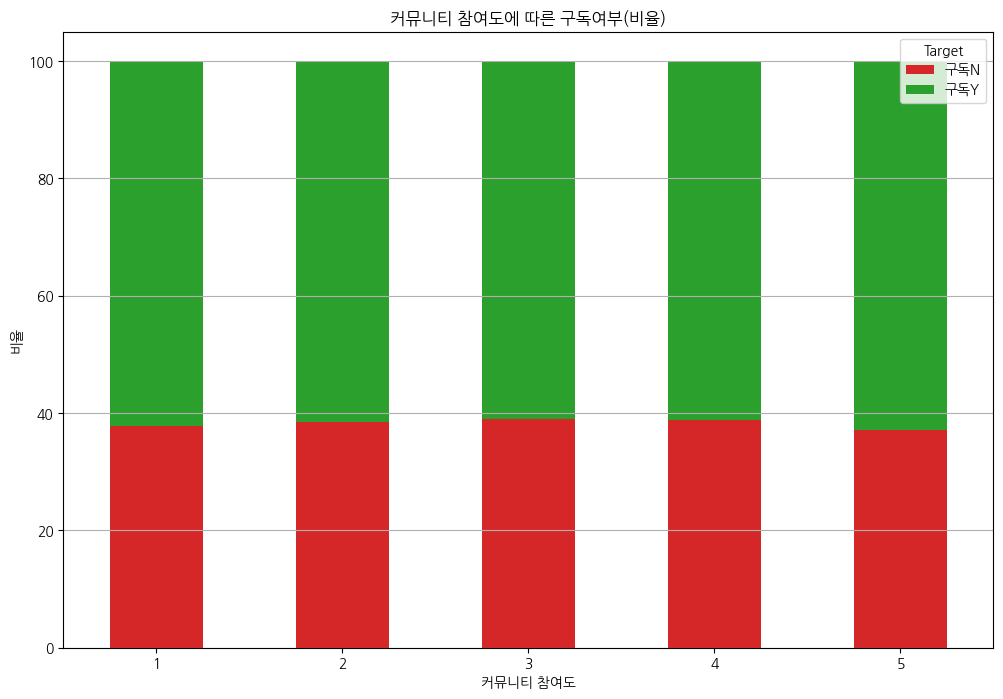

In [30]:
# community_engagement_level별로 target의 0과 1 카운트
engagement_counts = mini_data.groupby(['community_engagement_level', 'target']).size().unstack(fill_value=0)

# 각 community_engagement_level별 target의 0과 1의 합으로 나누어 비율 계산
engagement_percentages = engagement_counts.div(engagement_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = engagement_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('커뮤니티 참여도에 따른 구독여부(비율)')
plt.xlabel('커뮤니티 참여도')
plt.ylabel('비율')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가


plt.legend(title='Target', labels=['구독N', '구독Y'])
plt.show()

In [39]:
abandoned_counts = mini_data['abandoned_learning_sessions'].value_counts().sort_index()
print(abandoned_counts)

abandoned_learning_sessions
0      464
1     1485
2     2226
3     2195
4     1704
5     1026
6      530
7      237
8       91
9       27
10       9
11       4
12       2
Name: count, dtype: int64


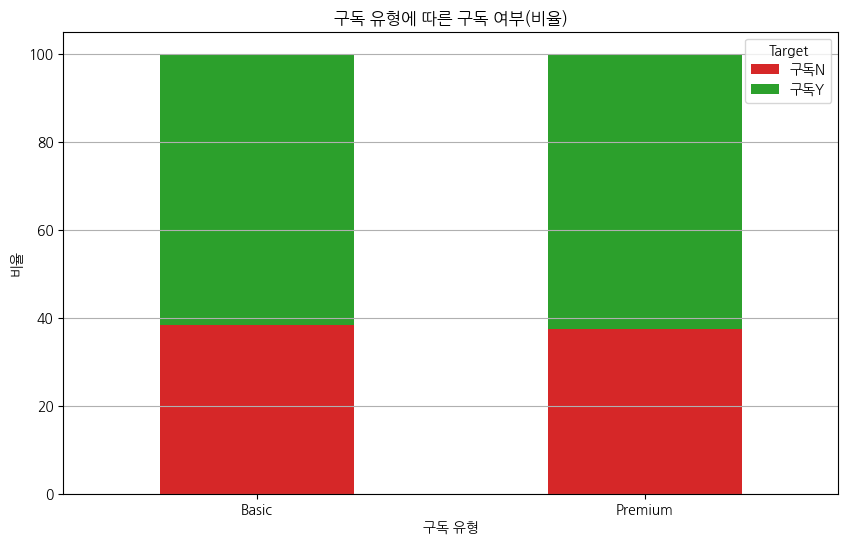

In [28]:
# subscription_type별로 target의 0과 1 카운트
subscription_counts = mini_data.groupby(['subscription_type', 'target']).size().unstack(fill_value=0)

# 각 subscription_type별 target의 0과 1의 합으로 나누어 비율 계산
subscription_percentages = subscription_counts.div(subscription_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = subscription_percentages.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#d62728', '#2ca02c'])
plt.title('구독 유형에 따른 구독 여부(비율)')
plt.xlabel('구독 유형')
plt.ylabel('비율')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가


plt.legend(title='Target', labels=['구독N', '구독Y'])
plt.show()

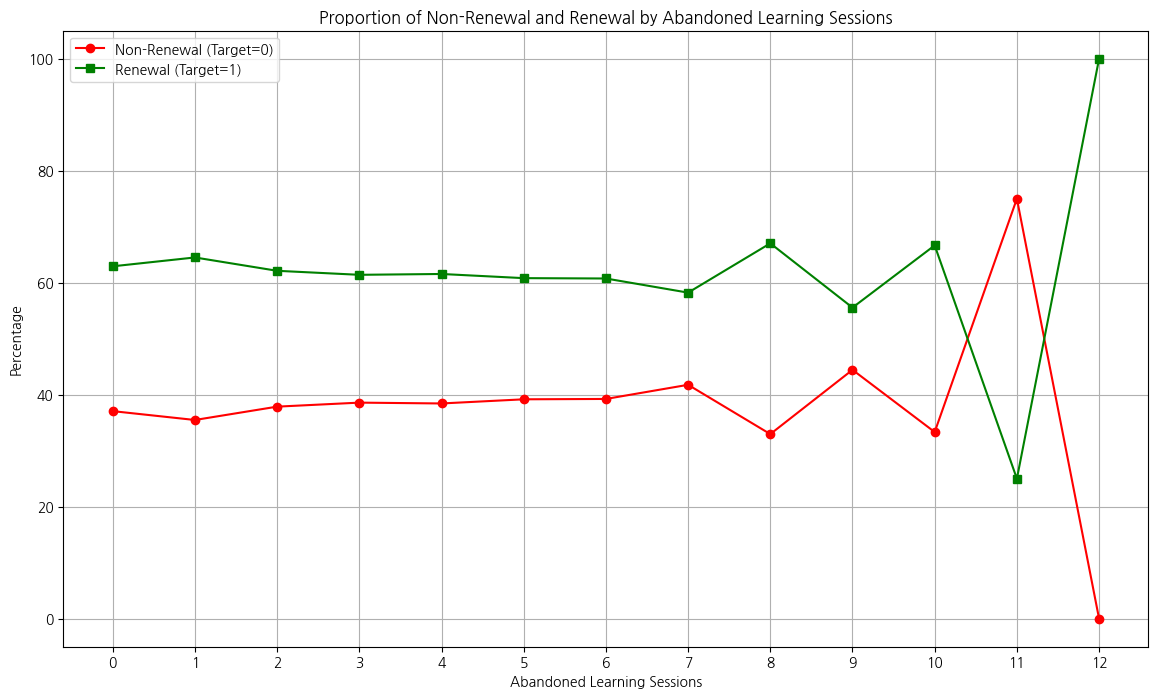

In [34]:
bins = list(range(0, 14))  # 0부터 12까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(13)]  # 0부터 12까지의 라벨

# 데이터 구간 나누기
mini_data['abandoned_bin'] = pd.cut(mini_data['abandoned_learning_sessions'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['abandoned_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 꺾은선 그래프 시각화
plt.figure(figsize=(14, 8))
plt.plot(bin_percentages.index, bin_percentages[0], marker='o', color='red', label='Non-Renewal (Target=0)')
plt.plot(bin_percentages.index, bin_percentages[1], marker='s', color='green', label='Renewal (Target=1)')
plt.title('Proportion of Non-Renewal and Renewal by Abandoned Learning Sessions')
plt.xlabel('Abandoned Learning Sessions')
plt.ylabel('Percentage')
plt.grid(True)


plt.legend()
plt.show()

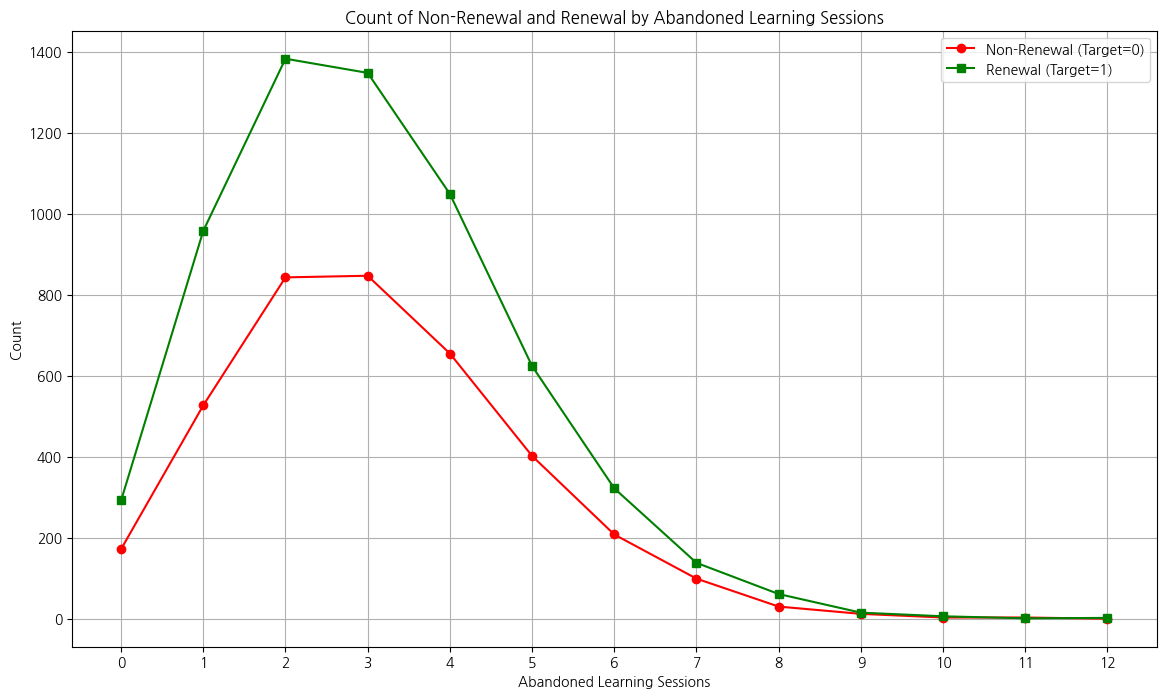

In [36]:
# 구간 설정
bins = list(range(0, 14))  # 0부터 12까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(13)]  # 0부터 12까지의 라벨

# 데이터 구간 나누기
mini_data['abandoned_bin'] = pd.cut(mini_data['abandoned_learning_sessions'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['abandoned_bin', 'target']).size().unstack(fill_value=0)

# 꺾은선 그래프 시각화
plt.figure(figsize=(14, 8))
plt.plot(bin_counts.index, bin_counts[0], marker='o', color='red', label='Non-Renewal (Target=0)')
plt.plot(bin_counts.index, bin_counts[1], marker='s', color='green', label='Renewal (Target=1)')
plt.title('Count of Non-Renewal and Renewal by Abandoned Learning Sessions')
plt.xlabel('Abandoned Learning Sessions')
plt.ylabel('Count')
plt.grid(True)


plt.legend()
plt.show()

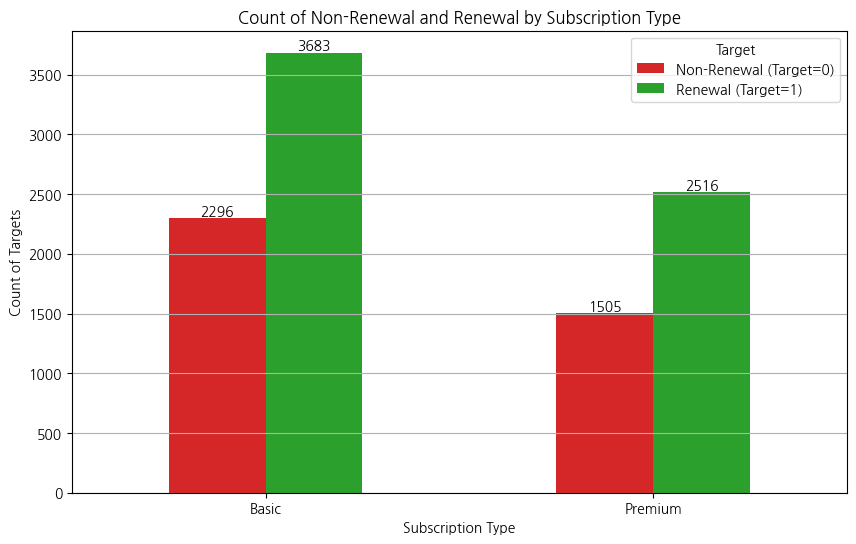

In [24]:
# subscription_type별로 target의 0과 1 카운트
subscription_counts = mini_data.groupby(['subscription_type', 'target']).size().unstack(fill_value=0)

# 바 차트 시각화
fig, ax = plt.subplots(figsize=(10, 6))
subscription_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])
plt.title('Count of Non-Renewal and Renewal by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Count of Targets')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 수치 표시 추가
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 수치가 0보다 클 때만 표시
        ax.text(p.get_x() + p.get_width() / 2., height, f'{int(height)}', ha='center', va='bottom')

plt.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.show()

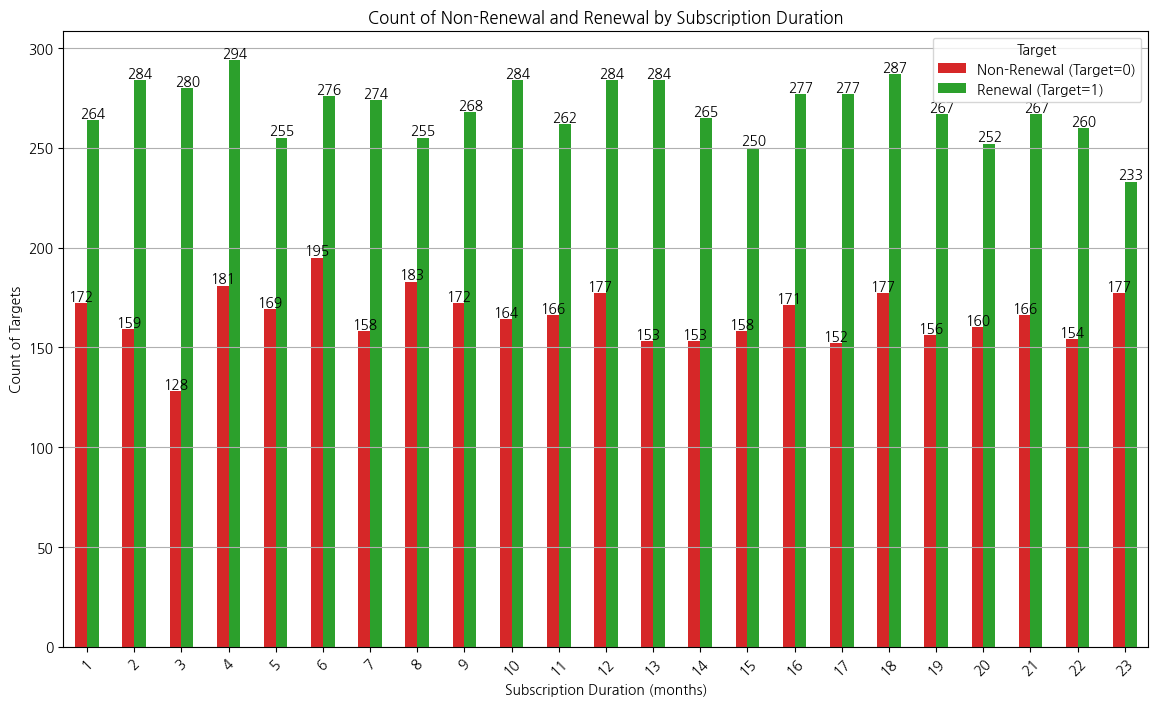

In [25]:
# 구간 설정
bins = list(range(1, 25))  # 1부터 23까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(1, 24)]  # 1부터 23까지의 라벨

# 데이터 구간 나누기
mini_data['duration_bin'] = pd.cut(mini_data['subscription_duration'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['duration_bin', 'target']).size().unstack(fill_value=0)

# 바 차트 생성
fig, ax = plt.subplots(figsize=(14, 8))
bin_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])

# 그래프 세부 설정
ax.set_title('Count of Non-Renewal and Renewal by Subscription Duration')
ax.set_xlabel('Subscription Duration (months)')
ax.set_ylabel('Count of Targets')
ax.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 수치 표시 추가
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 수치가 0보다 클 때만 표시
        ax.text(p.get_x() + p.get_width() / 2., height, f'{int(height)}', ha='center', va='bottom')

plt.show()

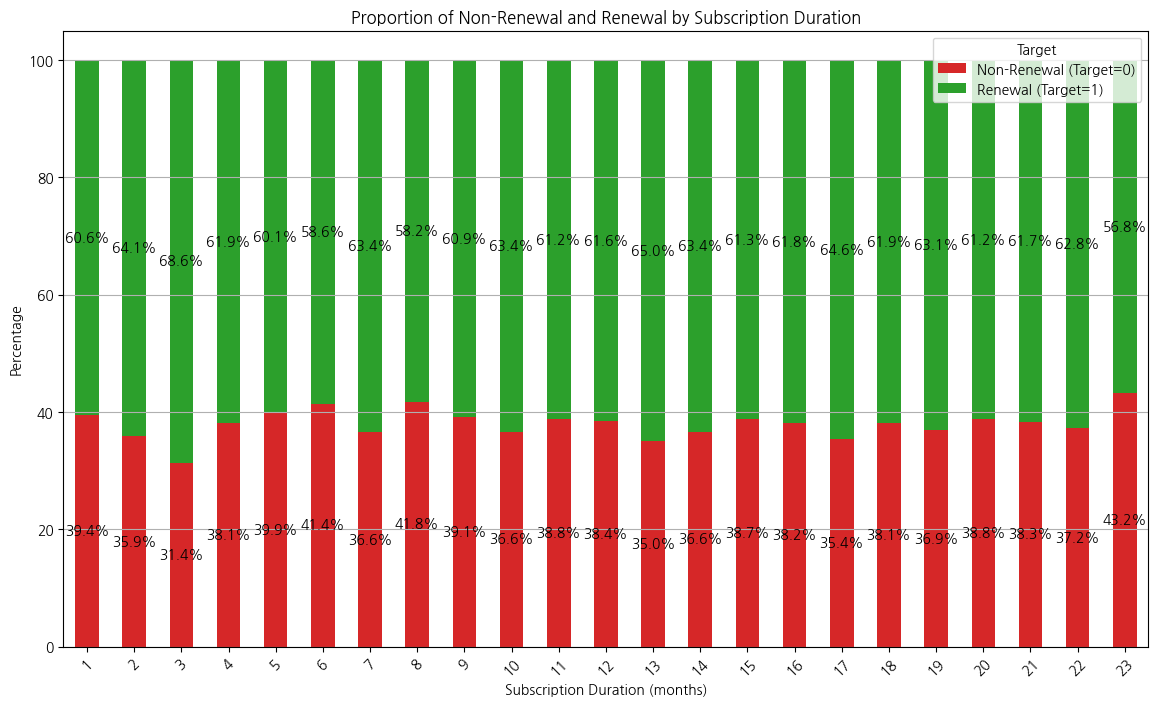

In [26]:
# 구간 설정
bins = list(range(1, 25))  # 1부터 23까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(1, 24)]  # 1부터 23까지의 라벨

# 데이터 구간 나누기
mini_data['duration_bin'] = pd.cut(mini_data['subscription_duration'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['duration_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(14, 8), color=['#d62728', '#2ca02c'])
plt.title('Proportion of Non-Renewal and Renewal by Subscription Duration')
plt.xlabel('Subscription Duration (months)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 비율 표시 추가
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:  # 비율이 0보다 클 때만 표시
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center')

plt.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.show()

In [41]:
payment_pattern_c = mini_data['payment_pattern'].value_counts().sort_index()
print(payment_pattern_c)

payment_pattern
0    1275
1    1285
2    1206
3    1230
4    1214
5    1238
6    1268
7    1284
Name: count, dtype: int64


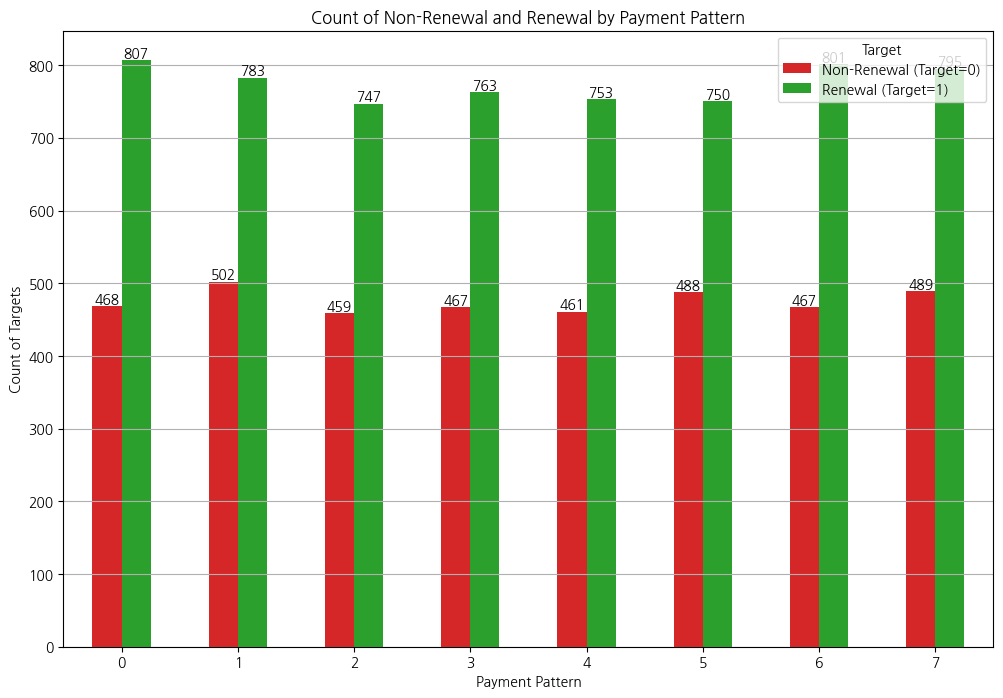

In [42]:
# payment_pattern 별로 target의 0과 1 카운트
payment_pattern_counts = mini_data.groupby(['payment_pattern', 'target']).size().unstack(fill_value=0)

# 바 차트 생성
fig, ax = plt.subplots(figsize=(12, 8))
payment_pattern_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])

# 그래프 세부 설정
ax.set_title('Count of Non-Renewal and Renewal by Payment Pattern')
ax.set_xlabel('Payment Pattern')
ax.set_ylabel('Count of Targets')
ax.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 수치 표시 추가
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 수치가 0보다 클 때만 표시
        ax.text(p.get_x() + p.get_width() / 2., height, f'{int(height)}', ha='center', va='bottom')

plt.show()

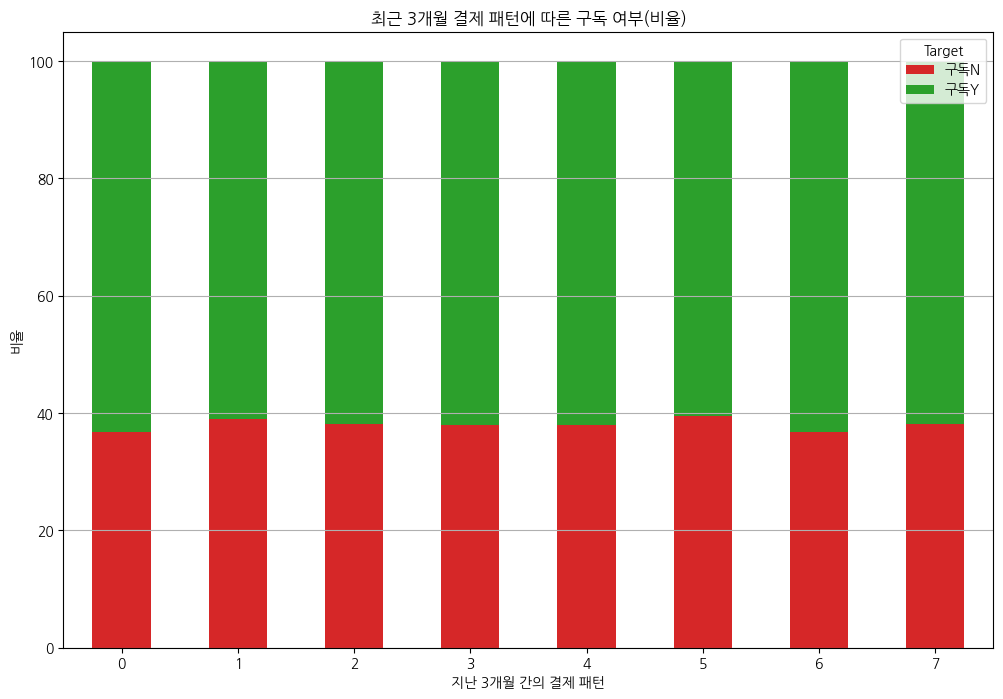

In [44]:
# payment_pattern 별로 target의 0과 1 카운트
payment_pattern_counts = mini_data.groupby(['payment_pattern', 'target']).size().unstack(fill_value=0)

# 각 payment_pattern별 target의 0과 1의 합으로 나누어 비율 계산
payment_pattern_percentages = payment_pattern_counts.div(payment_pattern_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = payment_pattern_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('최근 3개월 결제 패턴에 따른 구독 여부(비율)')
plt.xlabel('지난 3개월 간의 결제 패턴')
plt.ylabel('비율')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가


plt.legend(title='Target', labels=['구독N', '구독Y'])
plt.show()

In [45]:
level=mini_data['preferred_difficulty_level'].value_counts().sort_index()
print(level)

preferred_difficulty_level
High      2000
Low       4992
Medium    3008
Name: count, dtype: int64


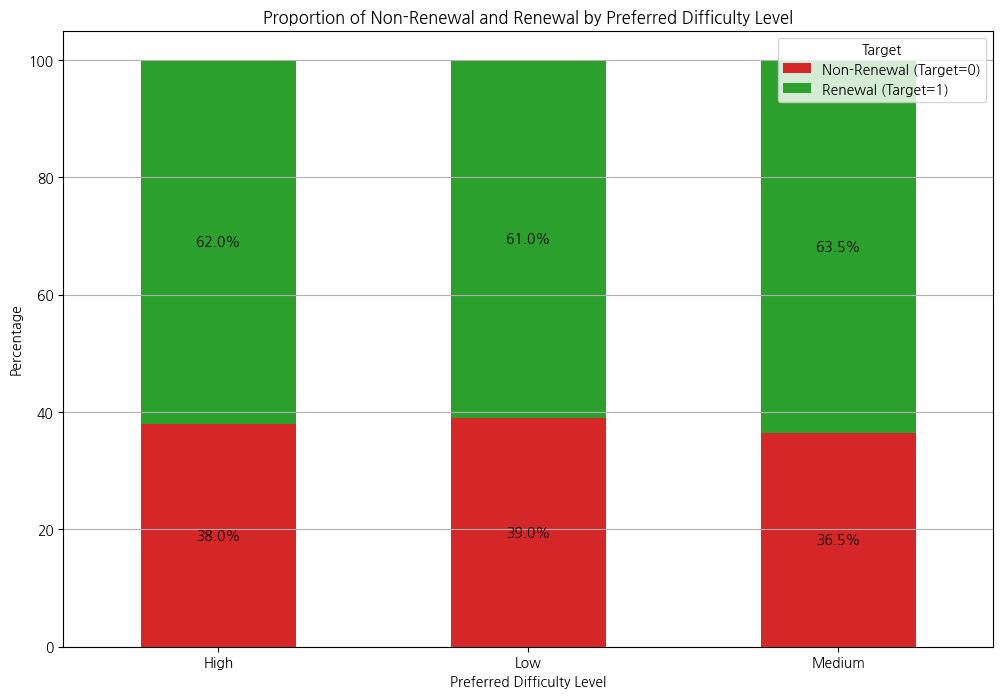

In [46]:
# preferred_difficulty_level별로 target의 0과 1 카운트
difficulty_counts = mini_data.groupby(['preferred_difficulty_level', 'target']).size().unstack(fill_value=0)

# 각 preferred_difficulty_level별 target의 0과 1의 합으로 나누어 비율 계산
difficulty_percentages = difficulty_counts.div(difficulty_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = difficulty_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('Proportion of Non-Renewal and Renewal by Preferred Difficulty Level')
plt.xlabel('Preferred Difficulty Level')
plt.ylabel('Percentage')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 비율 표시 추가
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:  # 비율이 0보다 클 때만 표시
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center')

plt.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.show()

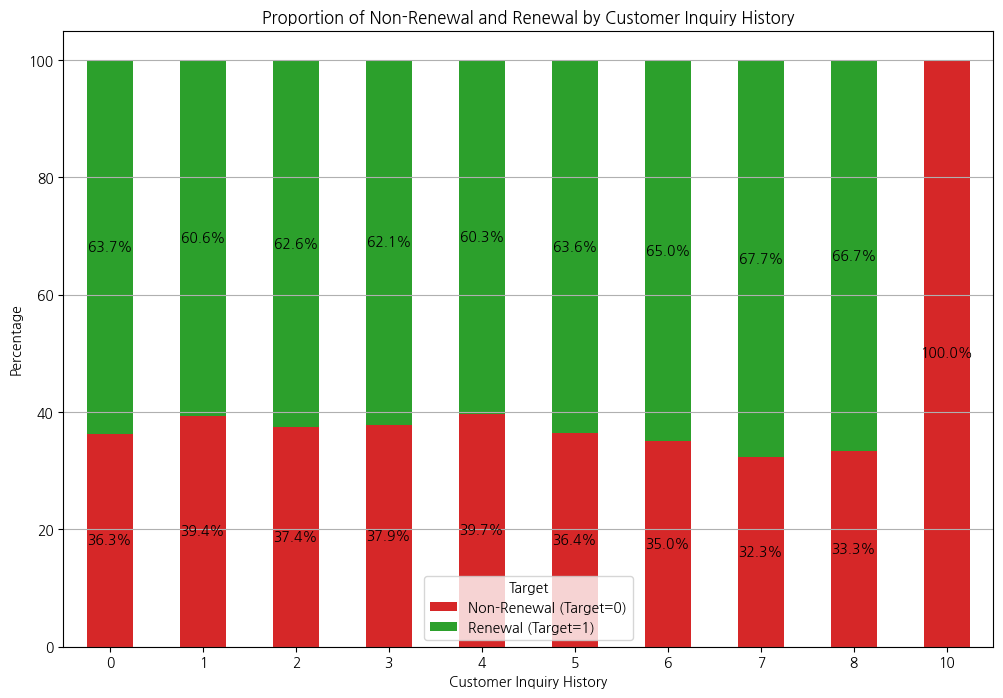

In [47]:
# customer_inquiry_history 값을 그룹화하여 target의 0과 1 카운트
inquiry_counts = mini_data.groupby(['customer_inquiry_history', 'target']).size().unstack(fill_value=0)

# 각 customer_inquiry_history별 target의 0과 1의 합으로 나누어 비율 계산
inquiry_percentages = inquiry_counts.div(inquiry_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = inquiry_percentages.plot(kind='bar', stacked=True, figsize=(12, 8), color=['#d62728', '#2ca02c'])
plt.title('Proportion of Non-Renewal and Renewal by Customer Inquiry History')
plt.xlabel('Customer Inquiry History')
plt.ylabel('Percentage')
plt.xticks(rotation=0)  # X축 라벨 회전 없음
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 비율 표시 추가
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:  # 비율이 0보다 클 때만 표시
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center')

plt.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.show()

In [48]:
c_h=mini_data['customer_inquiry_history'].value_counts().sort_index()
print(c_h)

customer_inquiry_history
0     1376
1     2668
2     2645
3     1851
4      917
5      385
6      117
7       31
8        9
10       1
Name: count, dtype: int64


In [49]:
a_lt=mini_data['average_login_time'].value_counts().sort_index() 
print(a_lt)

average_login_time
2.366189     1
3.375170     1
3.483285     1
3.636424     1
3.970000     1
            ..
25.408557    1
25.815833    1
26.125596    1
26.284396    1
26.998490    1
Name: count, Length: 10000, dtype: int64


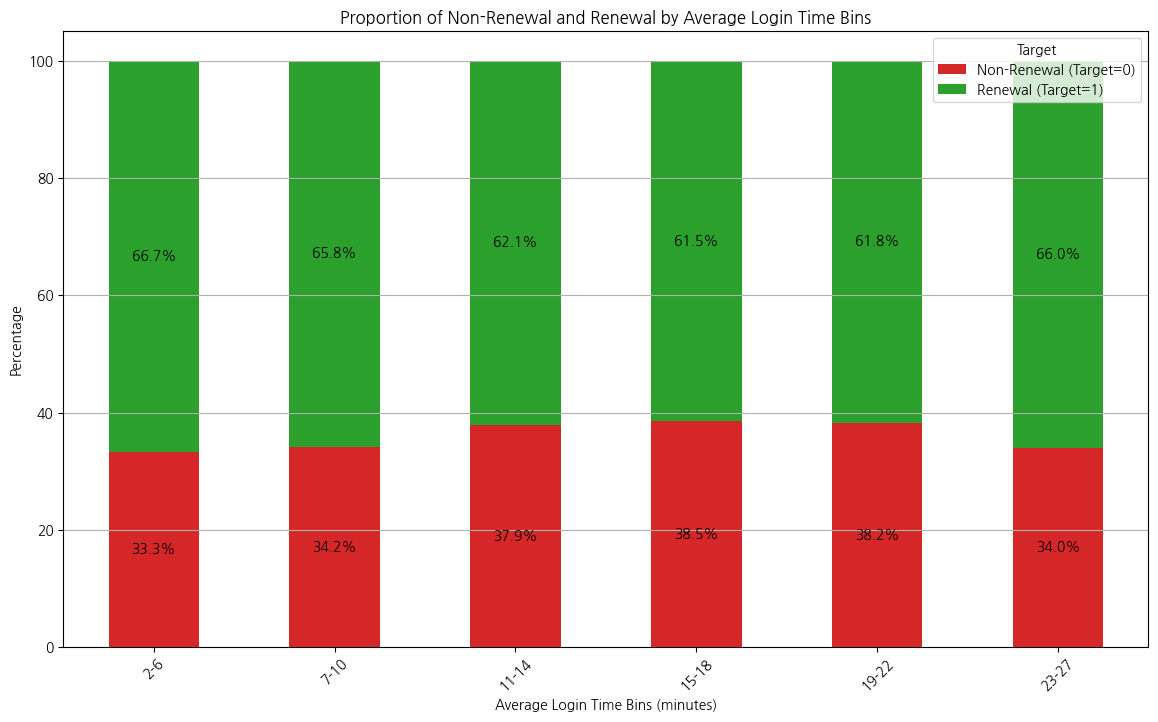

In [50]:
# 구간 설정
bins = [2, 6, 10, 14, 18, 22, 27]  # 최소값 2.366189, 최대값 26.998490을 포함하여 적절한 구간 분할
labels = ['2-6', '7-10', '11-14', '15-18', '19-22', '23-27']

# 데이터 구간 나누기
mini_data['login_time_bin'] = pd.cut(mini_data['average_login_time'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['login_time_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(14, 8), color=['#d62728', '#2ca02c'])
plt.title('Proportion of Non-Renewal and Renewal by Average Login Time Bins')
plt.xlabel('Average Login Time Bins (minutes)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 비율 표시 추가
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:  # 비율이 0보다 클 때만 표시
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center')

plt.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.show()

In [51]:
r_lt=mini_data['recent_login_time'].value_counts().sort_index() 
print(r_lt)

recent_login_time
1     347
2     350
3     349
4     332
5     355
6     362
7     322
8     322
9     350
10    335
11    306
12    365
13    363
14    366
15    325
16    347
17    354
18    336
19    380
20    362
21    333
22    349
23    338
24    328
25    323
26    359
27    370
28    313
29    359
Name: count, dtype: int64


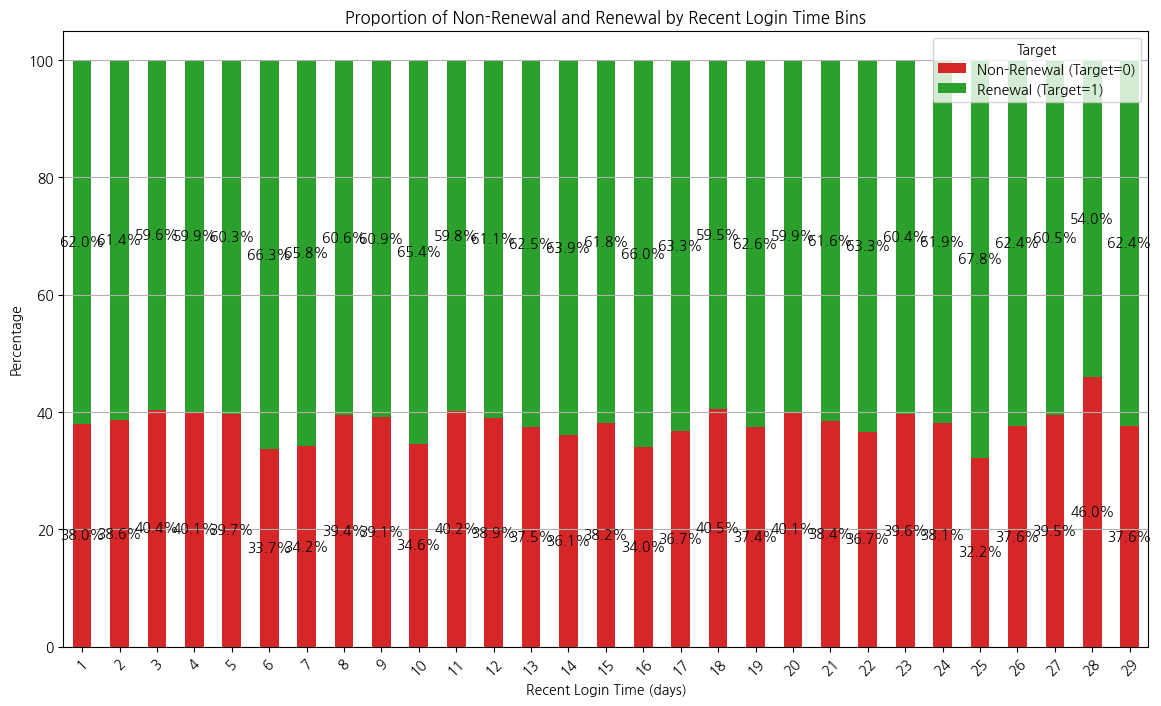

In [52]:
# 구간 설정
bins = list(range(1, 31))  # 1부터 29까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(1, 30)]  # 1부터 29까지의 라벨

# 데이터 구간 나누기
mini_data['login_time_bin'] = pd.cut(mini_data['recent_login_time'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['login_time_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 스택드 바 차트 시각화
ax = bin_percentages.plot(kind='bar', stacked=True, figsize=(14, 8), color=['#d62728', '#2ca02c'])
plt.title('Proportion of Non-Renewal and Renewal by Recent Login Time Bins')
plt.xlabel('Recent Login Time (days)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)  # X축 라벨 회전
plt.grid(True, axis='y')  # Y축에만 그리드 추가

# 비율 표시 추가
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:  # 비율이 0보다 클 때만 표시
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center')

plt.legend(title='Target', labels=['Non-Renewal (Target=0)', 'Renewal (Target=1)'])
plt.show()

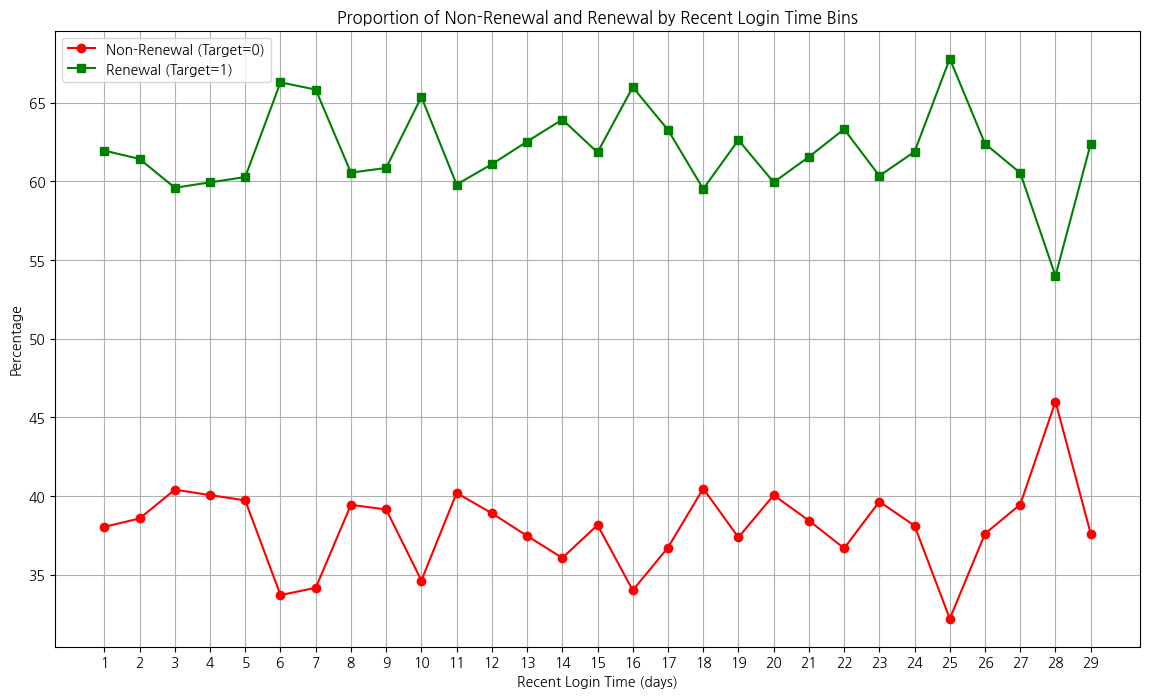

In [54]:
# 구간 설정
bins = list(range(1, 31))  # 1부터 29까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(1, 30)]  # 1부터 29까지의 라벨

# 데이터 구간 나누기
mini_data['login_time_bin'] = pd.cut(mini_data['recent_login_time'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts = mini_data.groupby(['login_time_bin', 'target']).size().unstack(fill_value=0)

# 각 구간별 target의 0과 1의 합으로 나누어 비율 계산
bin_percentages = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

# 꺾은선 그래프 시각화
plt.figure(figsize=(14, 8))
plt.plot(bin_percentages.index, bin_percentages[0], marker='o', color='red', label='Non-Renewal (Target=0)')
plt.plot(bin_percentages.index, bin_percentages[1], marker='s', color='green', label='Renewal (Target=1)')
plt.title('Proportion of Non-Renewal and Renewal by Recent Login Time Bins')
plt.xlabel('Recent Login Time (days)')
plt.ylabel('Percentage')
plt.grid(True)


plt.legend()
plt.show()

In [57]:
# target 변수를 제외한 상관관계 계산
correlation_matrix = mini_data.drop(columns=['target']).corr()

# 히트맵 시각화
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

ValueError: could not convert string to float: 'b919c29d'

user_id                                object
subscription_duration                   int64
recent_login_time                       int64
average_login_time                    float64
average_time_per_learning_session     float64
monthly_active_learning_days            int64
total_completed_courses                 int64
recent_learning_achievement           float64
abandoned_learning_sessions             int64
community_engagement_level              int64
preferred_difficulty_level             object
subscription_type                      object
customer_inquiry_history                int64
payment_pattern                         int64
target                                  int64
active_days_bin                      category
time_bin                             category
completed_courses_bin                category
achievement_bin                      category
abandoned_bin                        category
duration_bin                         category
login_time_bin                    

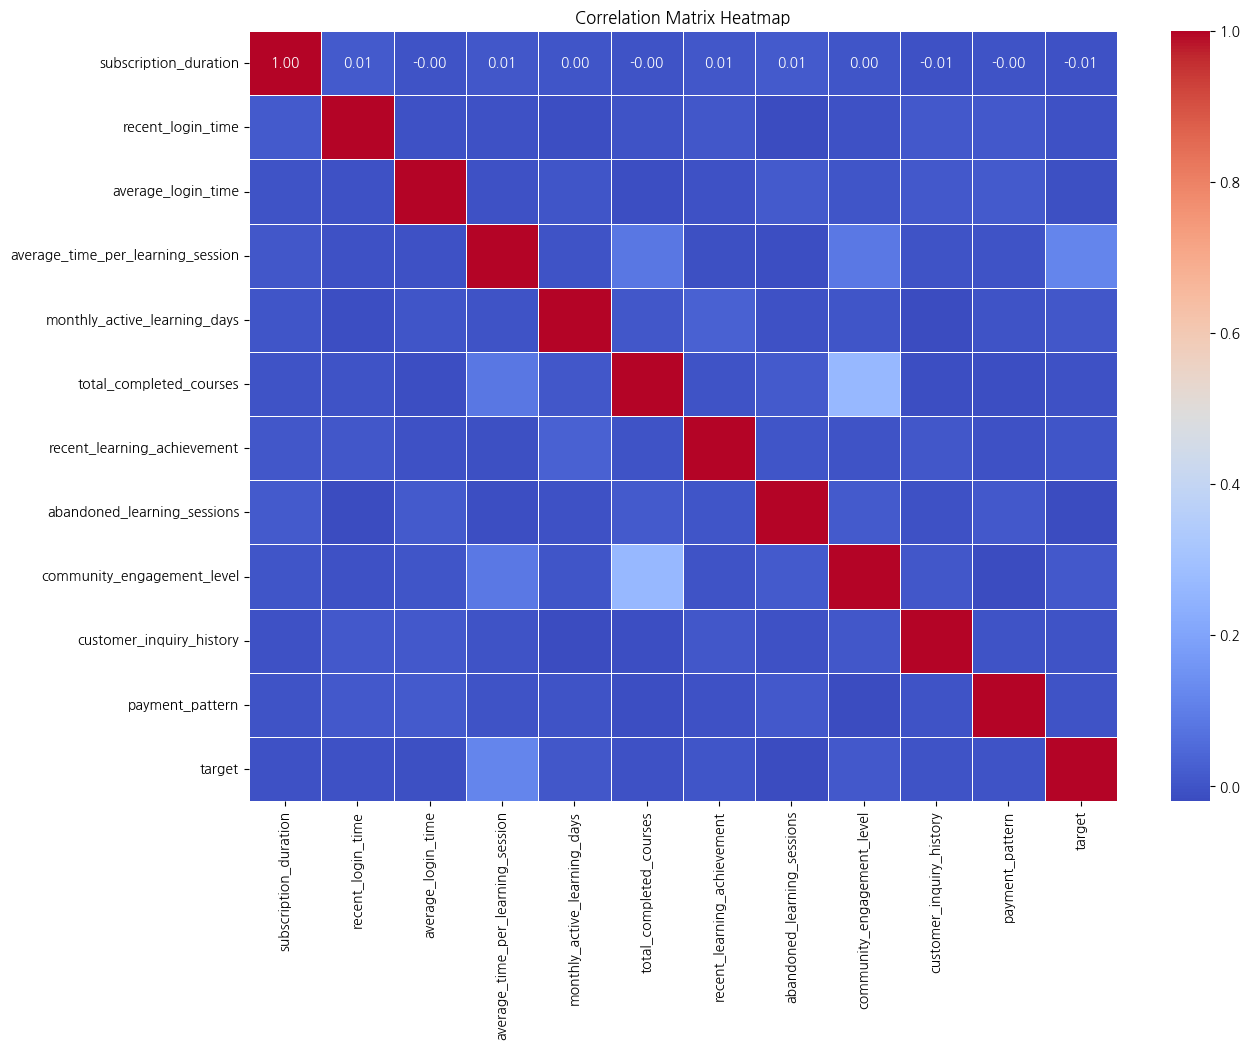

In [58]:
# 데이터 타입 확인
print(mini_data.dtypes)

# 수치형 데이터만 선택
numeric_data = mini_data.select_dtypes(include=[float, int])

# 상관관계 계산
correlation_matrix = numeric_data.corr()

# 히트맵 시각화
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

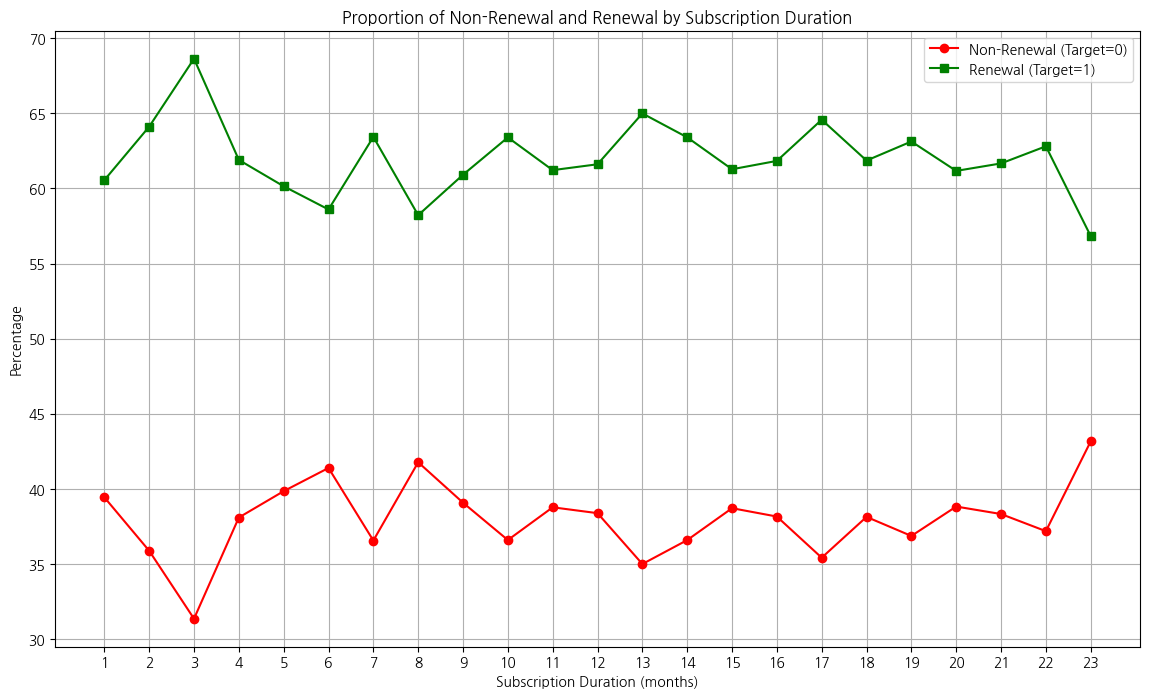

In [60]:
# 구간 설정
bins = list(range(1, 25))  # 1부터 23까지 각각 독립적인 구간으로 설정
labels = [str(x) for x in range(1, 24)]  # 1부터 23까지의 라벨

# 데이터 구간 나누기
mini_data['duration_bin'] = pd.cut(mini_data['subscription_duration'], bins=bins, labels=labels, right=False)

# 구간별로 target의 0과 1 카운트
bin_counts_duration = mini_data.groupby(['duration_bin', 'target']).size().unstack(fill_value=0)

# 비율 계산
bin_percentages_duration = bin_counts_duration.div(bin_counts_duration.sum(axis=1), axis=0) * 100

# 꺾은선 그래프 시각화
plt.figure(figsize=(14, 8))
plt.plot(bin_percentages_duration.index, bin_percentages_duration[0], marker='o', color='red', label='Non-Renewal (Target=0)')
plt.plot(bin_percentages_duration.index, bin_percentages_duration[1], marker='s', color='green', label='Renewal (Target=1)')
plt.title('Proportion of Non-Renewal and Renewal by Subscription Duration')
plt.xlabel('Subscription Duration (months)')
plt.ylabel('Percentage')
plt.grid(True)

plt.legend()
plt.show()

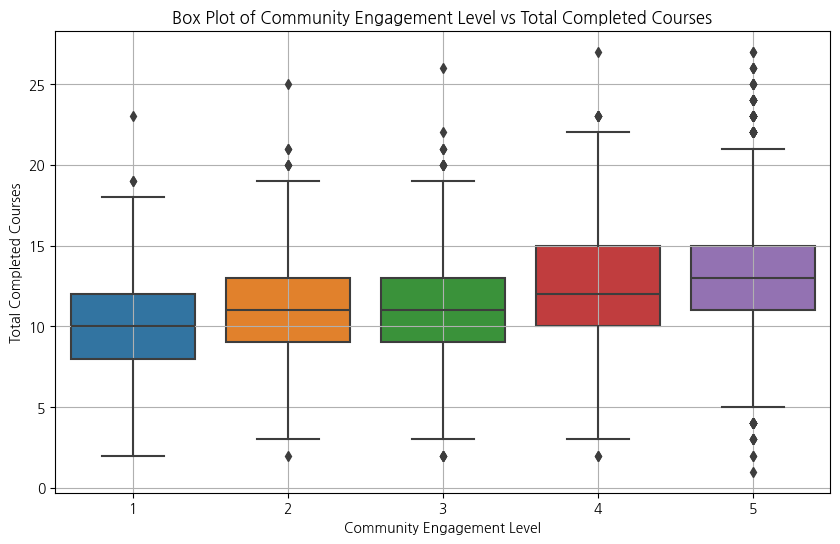

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='community_engagement_level', y='total_completed_courses', data=mini_data)
plt.title('Box Plot of Community Engagement Level vs Total Completed Courses')
plt.xlabel('Community Engagement Level')
plt.ylabel('Total Completed Courses')
plt.grid(True)
plt.show()

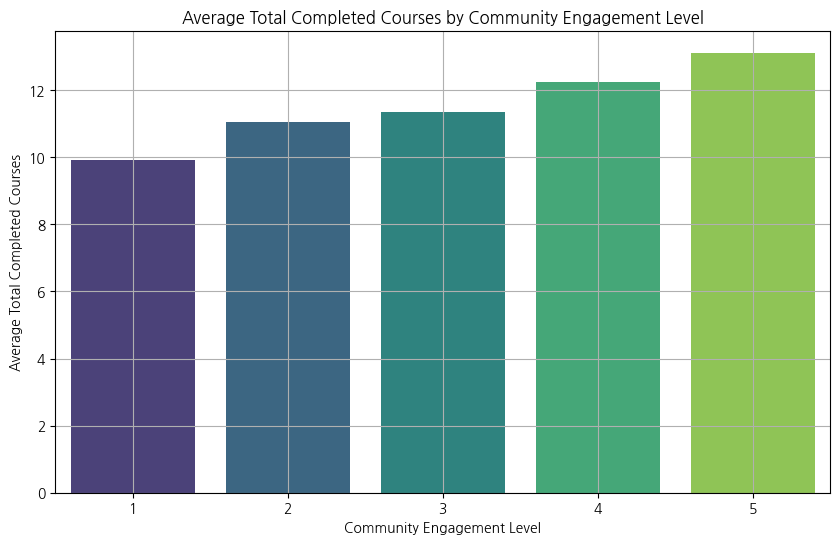

In [63]:
# 각 community_engagement_level에 따른 total_completed_courses의 평균 계산
mean_courses_by_engagement = mini_data.groupby('community_engagement_level')['total_completed_courses'].mean().reset_index()

# 바 차트 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='community_engagement_level', y='total_completed_courses', data=mean_courses_by_engagement, palette='viridis')
plt.title('Average Total Completed Courses by Community Engagement Level')
plt.xlabel('Community Engagement Level')
plt.ylabel('Average Total Completed Courses')
plt.grid(True)
plt.show()

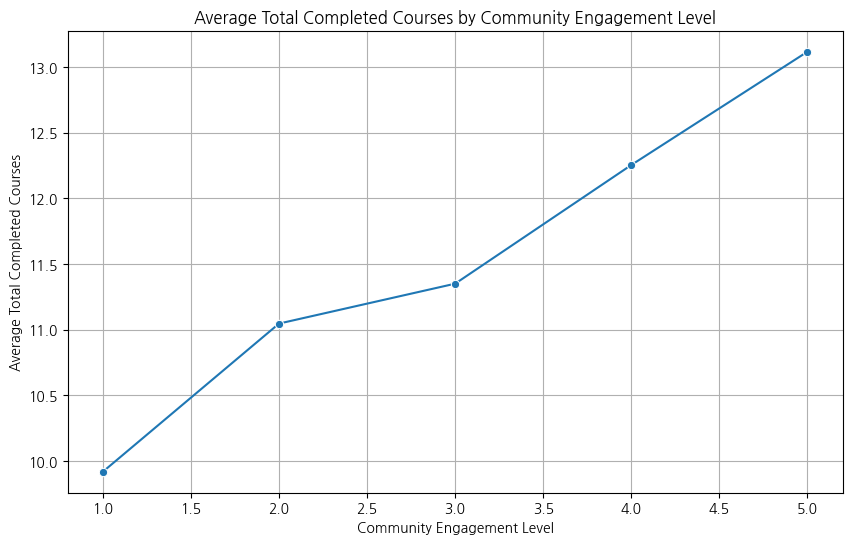

In [64]:
# 각 community_engagement_level에 따른 total_completed_courses의 평균 계산
mean_courses_by_engagement = mini_data.groupby('community_engagement_level')['total_completed_courses'].mean().reset_index()

# 꺾은선 그래프 시각화
plt.figure(figsize=(10, 6))
sns.lineplot(x='community_engagement_level', y='total_completed_courses', data=mean_courses_by_engagement, marker='o')
plt.title('Average Total Completed Courses by Community Engagement Level')
plt.xlabel('Community Engagement Level')
plt.ylabel('Average Total Completed Courses')
plt.grid(True)
plt.show()

In [65]:
C_E_L=mini_data['community_engagement_level'].value_counts().sort_index() 
print(C_E_L)

community_engagement_level
1     559
2    1219
3    1588
4    2070
5    4564
Name: count, dtype: int64


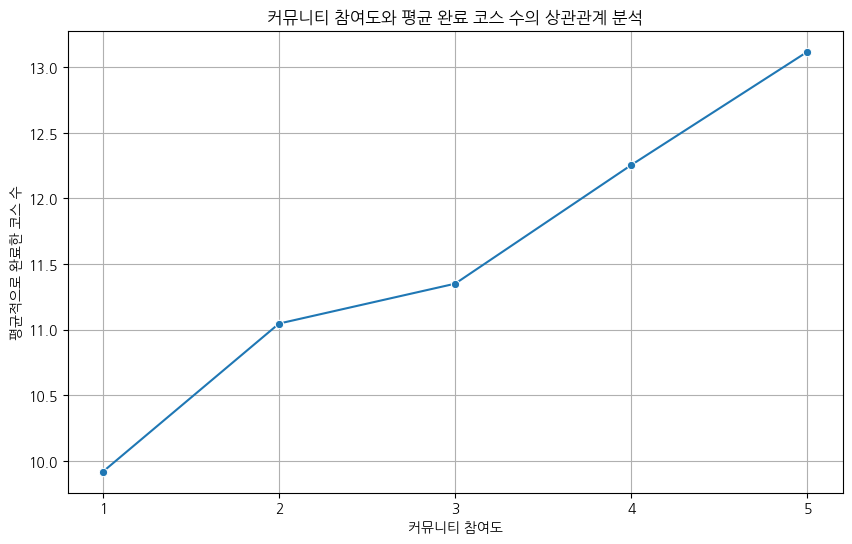

In [67]:
# 각 community_engagement_level에 따른 total_completed_courses의 평균 계산
mean_courses_by_engagement = mini_data.groupby('community_engagement_level')['total_completed_courses'].mean().reset_index()

# 꺾은선 그래프 시각화
plt.figure(figsize=(10, 6))
sns.lineplot(x='community_engagement_level', y='total_completed_courses', data=mean_courses_by_engagement, marker='o')
plt.title('커뮤니티 참여도와 평균 완료 코스 수의 상관관계 분석')
plt.xlabel('커뮤니티 참여도')
plt.ylabel('평균적으로 완료한 코스 수')
plt.grid(True)
plt.xticks(mean_courses_by_engagement['community_engagement_level'])  # X축 눈금을 정수값으로 설정
plt.show()

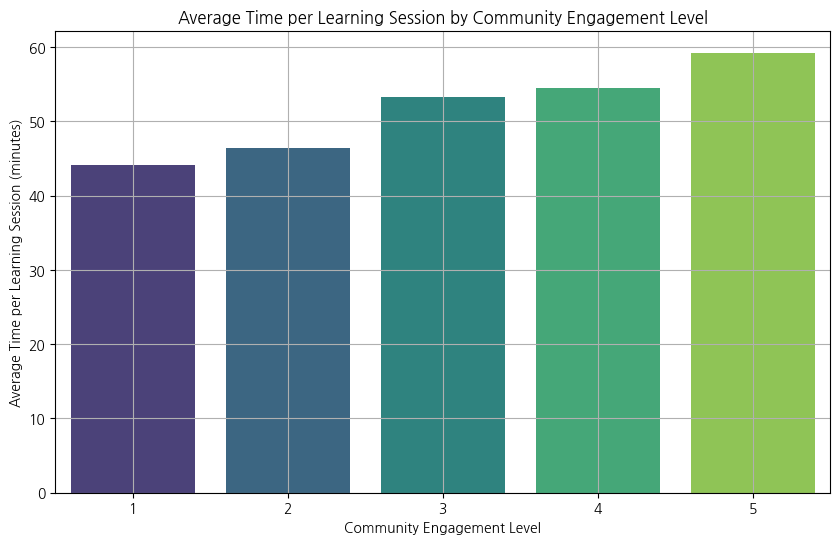

In [68]:
# 각 community_engagement_level에 따른 average_time_per_learning_session의 평균 계산
mean_time_by_engagement = mini_data.groupby('community_engagement_level')['average_time_per_learning_session'].mean().reset_index()

# 바 차트 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='community_engagement_level', y='average_time_per_learning_session', data=mean_time_by_engagement, palette='viridis')
plt.title('Average Time per Learning Session by Community Engagement Level')
plt.xlabel('Community Engagement Level')
plt.ylabel('Average Time per Learning Session (minutes)')
plt.grid(True)
plt.show()

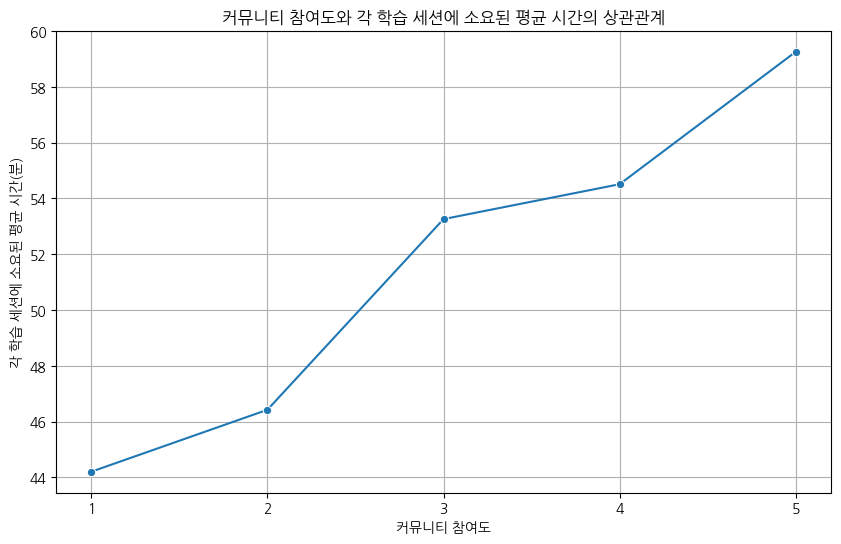

In [70]:
# 각 community_engagement_level에 따른 average_time_per_learning_session의 평균 계산
mean_time_by_engagement = mini_data.groupby('community_engagement_level')['average_time_per_learning_session'].mean().reset_index()

# 꺾은선 그래프 시각화
plt.figure(figsize=(10, 6))
sns.lineplot(x='community_engagement_level', y='average_time_per_learning_session', data=mean_time_by_engagement, marker='o')
plt.title('커뮤니티 참여도와 각 학습 세션에 소요된 평균 시간의 상관관계')
plt.xlabel('커뮤니티 참여도')
plt.ylabel('각 학습 세션에 소요된 평균 시간(분)')
plt.grid(True)
plt.xticks(mean_time_by_engagement['community_engagement_level'])  # X축 눈금을 정수값으로 설정
plt.show()

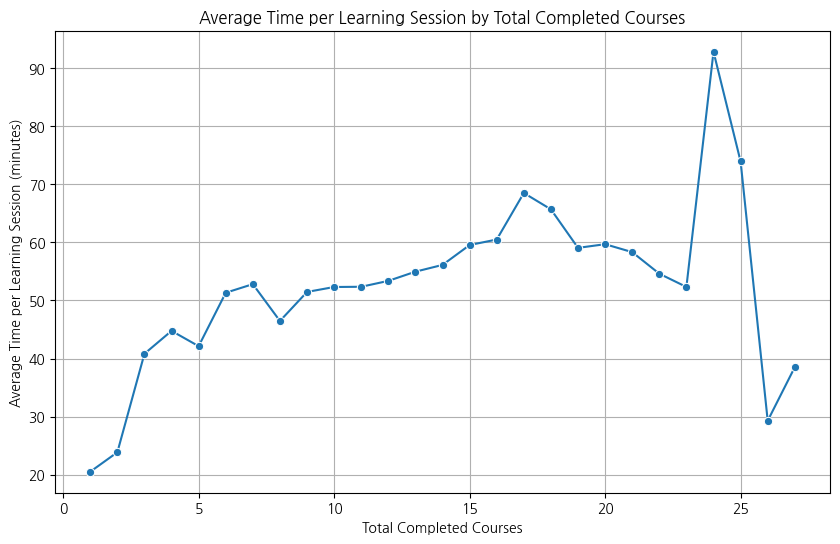

In [71]:
# 각 total_completed_courses에 따른 average_time_per_learning_session의 평균 계산
mean_time_by_completed_courses = mini_data.groupby('total_completed_courses')['average_time_per_learning_session'].mean().reset_index()

# 꺾은선 그래프 시각화
plt.figure(figsize=(10, 6))
sns.lineplot(x='total_completed_courses', y='average_time_per_learning_session', data=mean_time_by_completed_courses, marker='o')
plt.title('Average Time per Learning Session by Total Completed Courses')
plt.xlabel('Total Completed Courses')
plt.ylabel('Average Time per Learning Session (minutes)')
plt.grid(True)
plt.show()

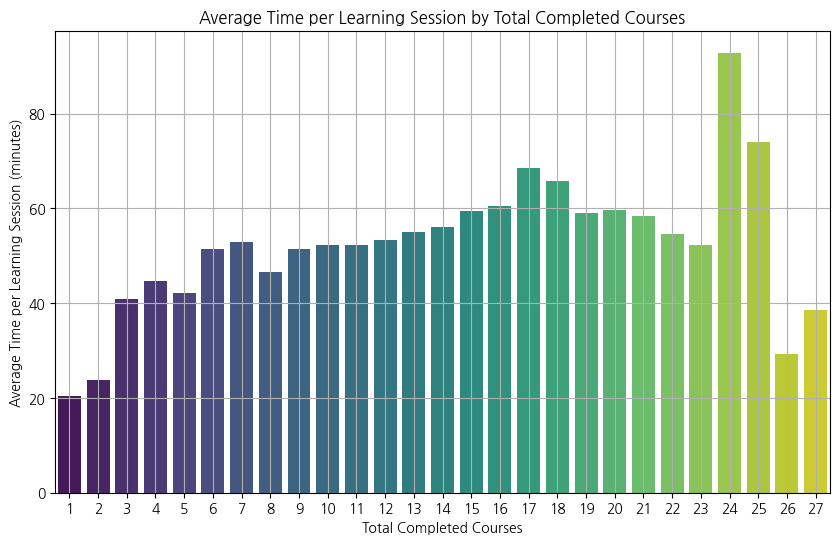

In [72]:
# 각 total_completed_courses에 따른 average_time_per_learning_session의 평균 계산
mean_time_by_completed_courses = mini_data.groupby('total_completed_courses')['average_time_per_learning_session'].mean().reset_index()

# 바 차트 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='total_completed_courses', y='average_time_per_learning_session', data=mean_time_by_completed_courses, palette='viridis')
plt.title('Average Time per Learning Session by Total Completed Courses')
plt.xlabel('Total Completed Courses')
plt.ylabel('Average Time per Learning Session (minutes)')
plt.grid(True)
plt.show()

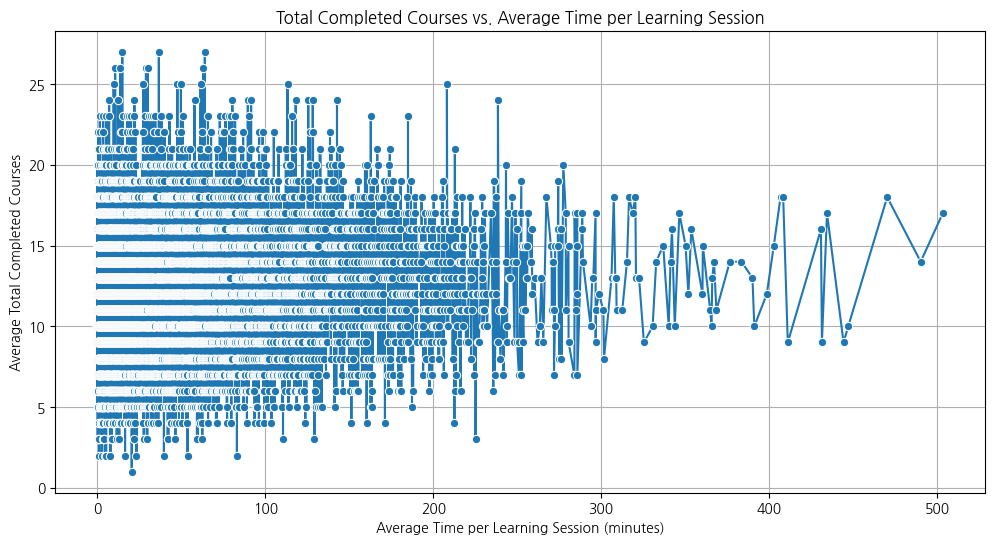

In [73]:
# 각 average_time_per_learning_session에 해당하는 유저 수를 user_id 값으로 그룹화하여 계산
user_counts_by_avg_time = mini_data.groupby('average_time_per_learning_session')['user_id'].nunique().reset_index()
user_counts_by_avg_time.columns = ['average_time_per_learning_session', 'user_count']

# average_time_per_learning_session별 total_completed_courses의 평균 계산
mean_courses_by_time = mini_data.groupby('average_time_per_learning_session')['total_completed_courses'].mean().reset_index()
mean_courses_by_time.columns = ['average_time_per_learning_session', 'average_total_completed_courses']

# 데이터 병합
merged_data = pd.merge(user_counts_by_avg_time, mean_courses_by_time, on='average_time_per_learning_session')

# 꺾은선 그래프 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=merged_data, x='average_time_per_learning_session', y='average_total_completed_courses', marker='o')
plt.title('Total Completed Courses vs. Average Time per Learning Session')
plt.xlabel('Average Time per Learning Session (minutes)')
plt.ylabel('Average Total Completed Courses')
plt.grid(True)
plt.show()

In [ ]:
# 피벗 테이블 생성: average_time_per_learning_session 별로 user_id의 개수를 계산
pivot_table = mini_data.pivot_table(values='user_id', index='average_time_per_learning_session', aggfunc='count').reset_index()
pivot_table.columns = ['average_time_per_learning_session', 'user_count']

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='average_time_per_learning_session', y='user_count', data=pivot_table, palette='viridis')
plt.title('User Count by Average Time per Learning Session')
plt.xlabel('Average Time per Learning Session (minutes)')
plt.ylabel('User Count')
plt.grid(True)
plt.show()